In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("all librarirs are imported ")

all librarirs are imported 


In [ ]:
df = pd.read_csv("AB_NYC_2019.csv")

Insight:
The Airbnb NYC 2019 dataset was successfully loaded into the notebook for further cleaning and analysis.

In [ ]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14884 entries, 0 to 14883
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14884 non-null  int64  
 1   name                            14872 non-null  object 
 2   host_id                         14884 non-null  int64  
 3   host_name                       14871 non-null  object 
 4   neighbourhood_group             14883 non-null  object 
 5   neighbourhood                   14883 non-null  object 
 6   latitude                        14883 non-null  float64
 7   longitude                       14883 non-null  float64
 8   room_type                       14883 non-null  object 
 9   price                           14883 non-null  float64
 10  minimum_nights                  14883 non-null  float64
 11  number_of_reviews               14883 non-null  float64
 12  last_review                     

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1.0,9.0,2018-10-19,0.21,6.0,365.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1.0,45.0,2019-05-21,0.38,2.0,355.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3.0,0.0,NaN,NaN,1.0,365.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1.0,270.0,2019-07-05,4.64,1.0,194.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10.0,9.0,2018-11-19,0.10,1.0,0.0


Insight:
The dataset contains 48,895 records and 16 columns. It includes information about listings, hosts, location, pricing, reviews, and availability.

# Missing value

In [ ]:
df.isnull().sum()

,0
id,0
name,12
host_id,0
host_name,13
neighbourhood_group,1
neighbourhood,1
latitude,1
longitude,1
room_type,1
price,1


Insight:
Missing values were found in the name, host_name, last_review, and reviews_per_month columns. These missing values need to be handled before performing further analysis.

In [ ]:
# Handling Missing Values

df['name'] = df['name'].fillna('Unknown')

df['host_name'] = df['host_name'].fillna('Unknown')

df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].median()
)

df['last_review'] = df['last_review'].fillna('Not Reviewed')

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,1
neighbourhood,1
latitude,1
longitude,1
room_type,1
price,1


Insight:
All missing values were successfully handled and no null values remain in the dataset.

# Duplicate data analysis

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# duplicate removal
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

Insight:
Duplicate records were removed to improve data quality and avoid biased analysis.

# Data standardization

In [ ]:
df['host_name'] = df['host_name'].str.title()

Insight:
Text values were standardized to maintain consistent formatting across the dataset.

# Outlier Detection

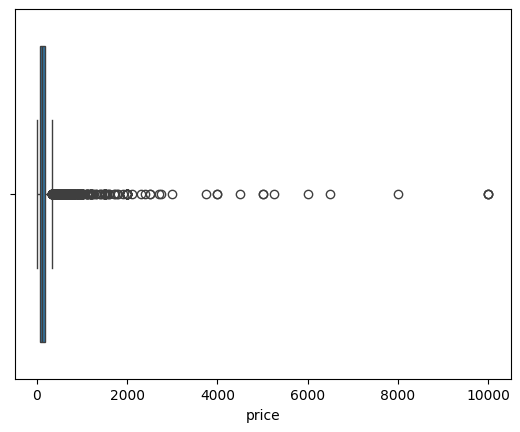

In [ ]:
sns.boxplot(x=df['price'])
plt.show()

In [ ]:
# Outlier Removal Using IQR Method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

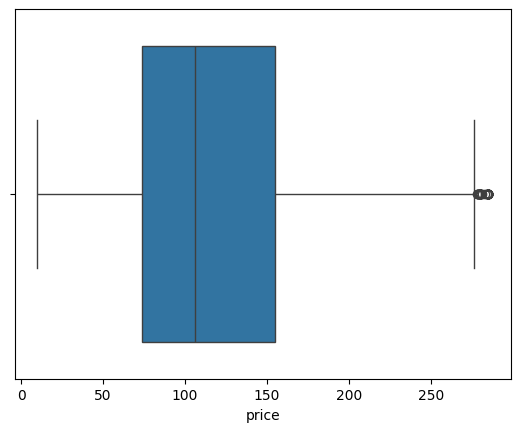

In [ ]:
sns.boxplot(x=df['price'])
plt.show()

Insight:
Extreme price values were removed using the IQR method, resulting in a more reliable dataset.

# Data type Conversion

In [ ]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

Insight:
The last_review column was converted into datetime format for improved date-based analysis.

# Export clean dataset

In [ ]:
df.to_csv("AB_NYC_2019_Cleaned.csv", index=False)

# Conclusion

The Airbnb NYC 2019 dataset was successfully cleaned and preprocessed. Missing values were handled, duplicate records were removed, text data was standardized, outliers were identified and treated, and date formats were corrected. These data cleaning steps significantly improved the quality, consistency, and reliability of the dataset. The final cleaned dataset is suitable for accurate analysis and future data-driven decision-making.
